# 03 — Inventory KPIs

## GulfMart Retail Inventory Analytics

This notebook computes core inventory KPIs at three grains -- **overall**,
**per-product**, and **per-store** -- across the full 3-year project
horizon. No monthly/quarterly trend in this pass; that is intentionally
out of scope here and could be a separate future notebook.

KPI logic lives in `src/inventory_kpis.py`, not in this notebook directly
-- this notebook loads data, calls that module, and presents the results.

**Data sources (deliberately mixed):**

- `dim_product`, `dim_store`, `fact_sales` -- read from **`data/cleaned/`**
  (post `02_data_cleaning.ipynb`)
- `fact_inventory` -- read from **`data/raw/`**. It was never modified by
  cleaning (see `02_data_cleaning.ipynb`), and its `sales_units` was built
  from `fact_sales` *before* the duplicate-transaction issue was planted,
  so it is already consistent with the cleaned `fact_sales`, not the raw
  (duplicated) one.

**Known modeling simplifications, stated upfront rather than hidden:**

- `unit_cost` is static per product for the entire 3-year period in this
  dataset -- there is no cost history to model, so inventory value and
  turnover reflect a "cost never changes" world.
- Inventory Turnover is computed as
  `Annualized COGS / Average Inventory Value`, where annualization scales
  the period's total COGS by `365 / period_days`. This is one reasonable
  convention among several; a different choice (e.g. using average daily
  COGS directly without annualizing) would rescale the number but not
  change which products/stores rank fastest vs. slowest.
- "Excess inventory" uses a fixed **365-day** average-coverage threshold
  (`EXCESS_COVERAGE_THRESHOLD_DAYS` in `src/inventory_kpis.py`), matching
  the threshold `src/data_validation.py` already uses for its own
  business-plausibility review. It is a defensible, but adjustable,
  cutoff -- not a law of nature.
- `fact_inventory` columns like `initial_opening_stock`, `lead_time_days`,
  and `safety_stock_days` are **static per product-store combination**
  (repeated across all 1,096 days). `inventory_kpis.py` explicitly
  de-duplicates before summing these -- summing them directly across the
  raw table would silently multiply them by the number of days in the
  group.


## 1. Setup

In [17]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root
SRC_DIR = PROJECT_ROOT / "src"
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_CLEANED_DIR = PROJECT_ROOT / "data" / "cleaned"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from inventory_kpis import (
    compute_inventory_value,
    compute_overall_kpis,
    compute_product_kpis,
    compute_store_kpis,
)

import importlib
import inventory_kpis
importlib.reload(inventory_kpis)
from inventory_kpis import compute_inventory_value, compute_overall_kpis, compute_product_kpis, compute_store_kpis

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Cleaned data: {DATA_CLEANED_DIR}")
print(f"Raw data:     {DATA_RAW_DIR}")


Project root: d:\GitHub\retail-inventory-analytics
Cleaned data: d:\GitHub\retail-inventory-analytics\data\cleaned
Raw data:     d:\GitHub\retail-inventory-analytics\data\raw


## 2. Load Data

Dimensions and sales from `data/cleaned/`; `fact_inventory` from
`data/raw/` (see note above).

In [18]:
dim_product = pd.read_csv(DATA_CLEANED_DIR / "dim_product.csv")
dim_store = pd.read_csv(DATA_CLEANED_DIR / "dim_store.csv")
fact_sales = pd.read_csv(DATA_CLEANED_DIR / "fact_sales.csv")
fact_inventory = pd.read_csv(DATA_RAW_DIR / "fact_inventory.csv.gz")

print(f"dim_product:    {len(dim_product):,} rows")
print(f"dim_store:      {len(dim_store):,} rows")
print(f"fact_sales:     {len(fact_sales):,} rows")
print(f"fact_inventory: {len(fact_inventory):,} rows")


dim_product:    500 rows
dim_store:      20 rows
fact_sales:     125,000 rows
fact_inventory: 10,960,000 rows


## 3. Compute Inventory Value

Joins `unit_cost`, `category`, and `demand_class` from `dim_product` onto
`fact_inventory`, and adds a row-level `inventory_value = closing_stock x
unit_cost` column that every downstream KPI function depends on.

In [19]:
fact_inventory_value = compute_inventory_value(fact_inventory, dim_product)



Computing Inventory Value
Rows: 10,960,000
Total inventory_value across all rows (all days): 13,860,198,026,465.43
(This is a period-cumulative figure, not a point-in-time balance --
 use compute_overall_kpis()/compute_product_kpis()/compute_store_kpis()
 for correctly time-averaged inventory value.)


## 4. Overall KPIs

Business-wide headline numbers for the full 3-year period.

In [20]:
overall_kpis = compute_overall_kpis(fact_inventory_value, fact_sales)

overall_kpis_df = pd.DataFrame([overall_kpis]).T.rename(columns={0: "value"})
overall_kpis_df



Overall Inventory KPIs
period_days                         1,096
avg_inventory_units                 52,127,517.31
avg_inventory_value                 12,646,166,082.54
annualized_cogs                     43,981,216.91
inventory_turnover_annualized       0.00
days_of_inventory                   104,950.50
sell_through_pct                    0.53
stockout_rate_pct                   0.00
in_stock_rate_pct                   100.00
avg_coverage_days                   3,095.07
excess_inventory_share_pct          89.95
gross_margin_pct                    29.59
gmroi                               0.00
slow_moving_value_share_pct         3.71
dead_stock_combo_count              2,175
dead_stock_combo_share_pct          21.75


,value
period_days,"1,096.00"
avg_inventory_units,"52,127,517.31"
avg_inventory_value,"12,646,166,082.54"
annualized_cogs,"43,981,216.91"
inventory_turnover_annualized,0.00
days_of_inventory,"104,950.50"
sell_through_pct,0.53
stockout_rate_pct,0.00
in_stock_rate_pct,100.00
avg_coverage_days,"3,095.07"


## 5. Product-Level KPIs

Same KPI family, aggregated per `product_id` across all stores.

In [21]:
product_kpis = compute_product_kpis(fact_inventory_value, fact_sales, dim_product)
product_kpis.head()



Product-Level Inventory KPIs
Computed KPIs for 500 products.


,avg_inventory_units,avg_inventory_value,beginning_inventory_units,total_receipts,stockout_rate_pct,avg_coverage_days,dead_store_count,total_cogs,gross_profit,net_sales,...,inventory_turnover_annualized,days_of_inventory,sell_through_pct,gross_margin_pct,gmroi,is_excess_inventory,product_id,product_name,category,demand_class
0,"169,827.67","67,003,808.09",1114,343945,0.00,"2,135.90",0,"1,380,890.00","425,150.31","1,806,040.31",...,0.01,"53,180.32",1.01,23.54,0.01,True,PROD0001,Frozen Foods Product 0001,Grocery,Fast-moving
1,"15,098.90","3,311,642.46",331,29600,0.00,"2,660.25",16,"1,754.64","1,161.99","2,916.63",...,0.00,"2,068,549.75",0.03,39.84,0.00,True,PROD0002,Accessories Product 0002,Fashion,Slow-moving
2,"41,313.76","9,168,762.76",673,81822,0.00,"1,329.46",1,"55,482.50","12,162.65","67,645.15",...,0.00,"181,119.52",0.30,17.98,0.00,True,PROD0003,Paper Products Product 0003,Household,Medium-moving
3,"140,182.41","17,726,065.82",620,280800,0.00,"4,961.57",2,"17,323.65","3,448.98","20,772.63",...,0.00,"1,121,459.28",0.05,16.60,0.00,True,PROD0004,Body Care Product 0004,Personal Care,Medium-moving
4,"29,999.88","3,260,087.11",628,59200,0.00,"2,309.16",12,"2,282.07",982.15,"3,264.22",...,0.00,"1,565,708.10",0.04,30.09,0.00,True,PROD0005,Water Product 0005,Beverages,Slow-moving


In [22]:
print("Top 10 products by inventory turnover (fastest-moving value):")
print(
    product_kpis.sort_values("inventory_turnover_annualized", ascending=False)[
        [
            "product_id",
            "product_name",
            "category",
            "demand_class",
            "inventory_turnover_annualized",
            "avg_coverage_days",
        ]
    ]
    .head(10)
    .to_string(index=False)
)

print()
print("Bottom 10 products by inventory turnover (slowest-moving value):")
print(
    product_kpis.sort_values("inventory_turnover_annualized", ascending=True)[
        [
            "product_id",
            "product_name",
            "category",
            "demand_class",
            "inventory_turnover_annualized",
            "avg_coverage_days",
        ]
    ]
    .head(10)
    .to_string(index=False)
)


Top 10 products by inventory turnover (fastest-moving value):
product_id                    product_name      category demand_class  inventory_turnover_annualized  avg_coverage_days
  PROD0075     Paper Products Product 0075     Household  Fast-moving                           0.02           1,335.06
  PROD0320          Cosmetics Product 0320        Beauty  Fast-moving                           0.02           1,300.69
  PROD0277        Accessories Product 0277       Fashion  Fast-moving                           0.02           1,602.46
  PROD0496      Smart Devices Product 0496   Electronics  Fast-moving                           0.02           1,471.19
  PROD0103       Canned Foods Product 0103       Grocery  Fast-moving                           0.02           1,387.06
  PROD0392             Juices Product 0392     Beverages  Fast-moving                           0.01           1,312.65
  PROD0441   Women's Clothing Product 0441       Fashion  Fast-moving                           0.

In [23]:
excess_products = product_kpis[product_kpis["is_excess_inventory"]]

print(
    f"Products flagged as excess inventory (avg coverage > 365 days): "
    f"{len(excess_products):,} of {len(product_kpis):,} "
    f"({len(excess_products) / len(product_kpis):.1%})"
)

print()
print("Top 10 products by dead_store_count (most stores with zero sales for that product):")
print(
    product_kpis.sort_values("dead_store_count", ascending=False)[
        ["product_id", "product_name", "category", "dead_store_count", "avg_coverage_days"]
    ]
    .head(10)
    .to_string(index=False)
)


Products flagged as excess inventory (avg coverage > 365 days): 496 of 500 (99.2%)

Top 10 products by dead_store_count (most stores with zero sales for that product):
product_id                    product_name      category  dead_store_count  avg_coverage_days
  PROD0058  Cleaning Supplies Product 0058     Household                20                NaN
  PROD0131              Water Product 0131     Beverages                20                NaN
  PROD0234     Paper Products Product 0234     Household                20                NaN
  PROD0091             Makeup Product 0091        Beauty                20                NaN
  PROD0380      Home Cleaning Product 0380     Household                19           1,910.95
  PROD0096           Footwear Product 0096       Fashion                19           3,731.44
  PROD0079              Water Product 0079     Beverages                19             904.38
  PROD0224          Oral Care Product 0224 Personal Care                19      

## 6. Store-Level KPIs

Same KPI family, aggregated per `store_id` across all products. Shown in
full since there are only 20 stores.

In [24]:
store_kpis = compute_store_kpis(fact_inventory_value, fact_sales, dim_store)

store_kpis_display = store_kpis.sort_values(
    "inventory_turnover_annualized", ascending=False
)[
    [
        "store_id",
        "store_name",
        "store_type",
        "region",
        "inventory_turnover_annualized",
        "days_of_inventory",
        "stockout_rate_pct",
        "avg_coverage_days",
        "gmroi",
        "dead_product_count",
    ]
]

store_kpis_display



Store-Level Inventory KPIs
Computed KPIs for 20 stores.


,store_id,store_name,store_type,region,inventory_turnover_annualized,days_of_inventory,stockout_rate_pct,avg_coverage_days,gmroi,dead_product_count
13,STORE014,GulfMart Store 014,Hypermarket,Western,0.01,"57,501.27",0.00,"2,697.94",0.01,85
14,STORE015,GulfMart Store 015,Hypermarket,Western,0.01,"60,672.49",0.00,"2,644.91",0.01,66
15,STORE016,GulfMart Store 016,E-commerce,Western,0.01,"71,090.27",0.00,"2,818.80",0.01,96
8,STORE009,GulfMart Store 009,Hypermarket,Southern,0.00,"81,699.93",0.00,"2,879.45",0.01,87
6,STORE007,GulfMart Store 007,Hypermarket,Southern,0.00,"82,771.24",0.00,"2,938.33",0.01,95
18,STORE019,GulfMart Store 019,Hypermarket,Southern,0.00,"83,403.22",0.00,"2,912.99",0.01,87
2,STORE003,GulfMart Store 003,Supermarket,Central,0.00,"86,929.64",0.00,"2,933.22",0.01,96
16,STORE017,GulfMart Store 017,Supermarket,Western,0.00,"94,463.56",0.00,"2,956.22",0.00,100
4,STORE005,GulfMart Store 005,Supermarket,Western,0.00,"97,078.21",0.00,"2,990.70",0.00,97
5,STORE006,GulfMart Store 006,Supermarket,Western,0.00,"101,518.44",0.00,"2,960.75",0.00,96


## 7. Visualizations

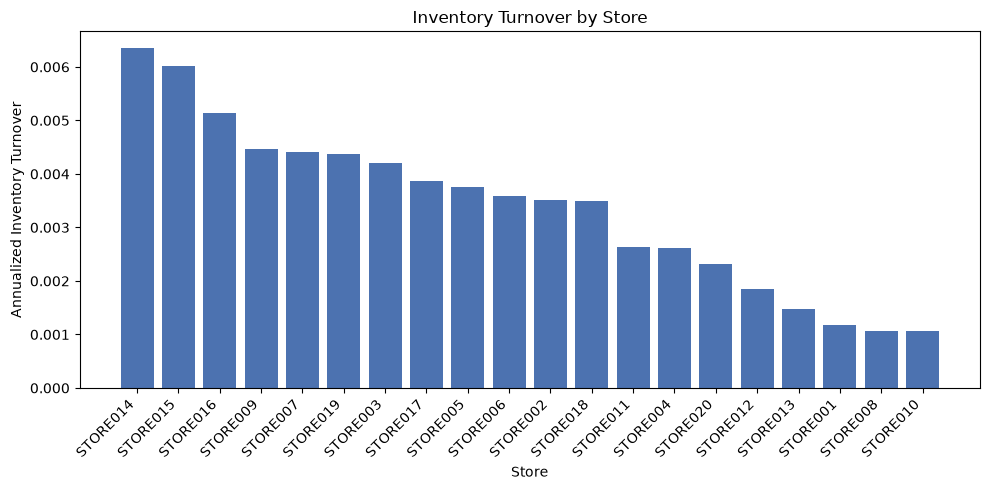

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

sorted_stores = store_kpis.sort_values("inventory_turnover_annualized", ascending=False)

ax.bar(sorted_stores["store_id"], sorted_stores["inventory_turnover_annualized"], color="#4C72B0")
ax.set_ylabel("Annualized Inventory Turnover")
ax.set_xlabel("Store")
ax.set_title("Inventory Turnover by Store")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


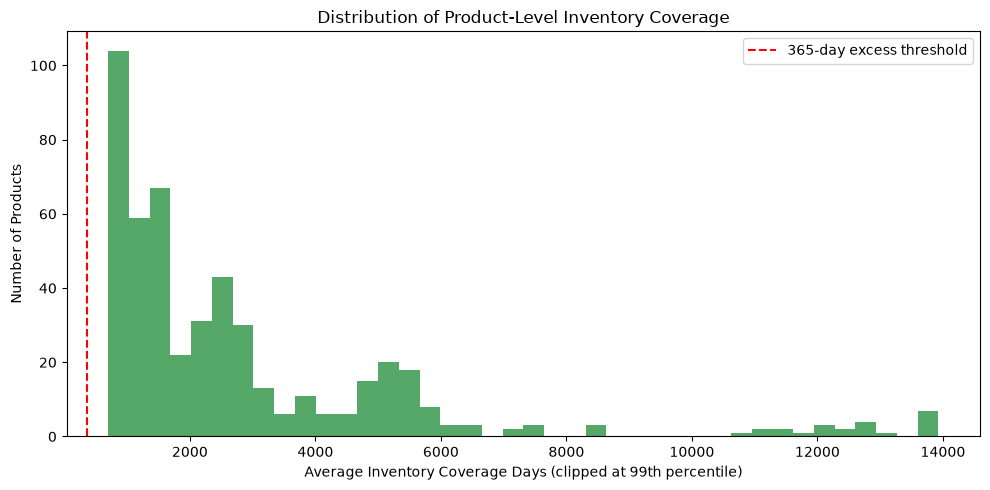

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

finite_coverage = (
    product_kpis["avg_coverage_days"].replace([np.inf, -np.inf], np.nan).dropna()
)
clipped_coverage = finite_coverage.clip(upper=finite_coverage.quantile(0.99))

ax.hist(clipped_coverage, bins=40, color="#55A868")
ax.axvline(365, color="red", linestyle="--", label="365-day excess threshold")
ax.set_xlabel("Average Inventory Coverage Days (clipped at 99th percentile)")
ax.set_ylabel("Number of Products")
ax.set_title("Distribution of Product-Level Inventory Coverage")
ax.legend()
plt.tight_layout()
plt.show()


## 8. Findings Summary

Update the numbers below after each run.

**Headline (overall) KPIs:** see Section 4's output table for the current
run's exact values -- summarize here in plain language once reviewed,
e.g. turnover level, stockout rate, average coverage days, GMROI.

**Expected narrative, based on prior profiling/validation runs:**

- Stockout events are at or near zero, and in-stock rate is at or near
  100% -- consistent with `01_data_profiling.ipynb`'s finding of
  well-calibrated (arguably over-calibrated) safety stock.
- A large share of inventory coverage sits well above the 365-day excess
  threshold -- consistent with `01_data_profiling.ipynb`'s finding that
  ~90% of inventory-days carry more than a year of coverage.
- A meaningful share of product-store combinations show zero sales for
  the entire period (dead stock) -- consistent with the ~22% of
  product-store combinations found to have no recorded sales in
  profiling.

**Overall read:** this system's core inventory risk is **excess /
overstock**, not stockouts -- worth stating plainly rather than treating
"zero stockouts" as an unqualified success, since it comes at the cost of
tied-up working capital. This framing should carry directly into
`05_overstock_analysis.ipynb`.

**Next step:** `04_stockout_analysis.ipynb` examines the (small) stockout
signal that does exist in more depth, before `05_overstock_analysis.ipynb`
digs into the larger excess-inventory story these KPIs point to.